In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier, StackingRegressor

import xgboost as xgb
import shap

#import tensorflow as tf
#from tensorflow.keras.models import Sequential, Model
#from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
#from tensorflow.keras.optimizers import Adam

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
#tf.random.set_seed(RANDOM_STATE)

print(f'XGBoost version : {xgb.__version__}')
#print(f'TensorFlow version : {tf.__version__}')

XGBoost version : 3.2.0


In [ ]:
import pandas as pd

df1 = pd.read_excel('2023.xlsx')
df2 = pd.read_excel('2024.xlsx')
df0 = pd.read_excel('Etat solde caisse agence 31 12 2022.xls')
df3 = pd.read_excel('2025.xlsx')

In [ ]:
f1 = df1.copy()
f2 = df2.copy()
f0 = df0.copy()
f3 = df3.copy()

In [ ]:
xls=pd.ExcelFile('2024.xlsx')
xls.sheet_names

['Feuil2', 'Exporter la feuille de calcul', 'Feuil1']

In [ ]:
df2 = pd.read_excel('2024.xlsx', sheet_name='Exporter la feuille de calcul')


In [ ]:
df1['MONTANT']=-df1['MONTANT']
df2['MONTANT']=-df2['MONTANT']
df0['SDE']=-df0['SDE']
df0

,,DCO,AGE,DEV,NCP,SDE
0,1,2022-12-31,0,788,1011100000,108519.23
1,2,2022-12-31,1,788,1011100000,145995.20
2,3,2022-12-31,2,788,1011100000,138429.89
3,4,2022-12-31,3,788,1011100000,204356.56
4,5,2022-12-31,4,788,1011100000,328733.70
...,...,...,...,...,...,...
9025,9026,2022-12-31,904,788,3728624000,-0.00
9026,9027,2022-12-31,916,788,3728624000,-0.00
9027,9028,2022-12-31,917,788,3728624000,-0.00
9028,9029,2022-12-31,920,788,3728624000,-0.00


In [ ]:
df1=f1.copy()
df1 = df1[df1['INTITULE_COMPTE'].isin([
    'CAISSE DINARS                 ',
    'CAISSES EN DINARS             '
])]

In [ ]:
df1

,index,CODE_AGENCE,DEV,CODE_OPERATION,LIBELLE_OPERATION,INTITULE_COMPTE,PERIODE,SENS,NB_OPERATION,MONTANT
27,1373958,8,788,101,TRANSFERT INTER CAISSES ESP,CAISSE DINARS,2023-03-03,C,1,140000.00
28,1373959,8,788,123,RETRAIT MAD,CAISSE DINARS,2023-01-11,C,1,300.00
29,1373960,8,788,194,RET TND SUR CPT DEV(ESCOMPTE),CAISSE DINARS,2023-01-24,C,1,16000.00
30,1373961,8,788,255,ENVOI FONDS BILLETS,CAISSE DINARS,2023-04-04,C,1,30000.00
31,1373962,8,788,306,WESTERN UNION,CAISSE DINARS,2023-07-21,C,1,275.86
...,...,...,...,...,...,...,...,...,...,...
739482,2113413,103,788,70,ACHAT PREP,CAISSE DINARS,2023-06-09,D,3,-50.70
739483,2113414,103,788,102,VERSEMENT ESPECE,CAISSE DINARS,2023-07-06,D,37,-111317.10
739484,2113415,103,788,102,VERSEMENT ESPECE,CAISSE DINARS,2023-08-04,D,30,-93989.50
739485,2113416,103,788,101,TRANSFERT INTER CAISSES ESP,CAISSE DINARS,2023-12-07,D,2,-57152.84


In [ ]:
df2.head()

,Index,CODE_AGENCE,DEV,CODE_OPERATION,LIBELLE_OPERATION,INTITULE_COMPTE,PERIODE,SENS,NB_OPERATION,MONTANT
0,651842,0,682,160,MOUVEMENT DE FONDS DEVISE,SAR MONNAIES ET MATIERES,2024-10-22,D,1,6000.00
1,651843,2,788,130,CHQ BANQUE,CHEQUES A PAYER SUR NOUS MEME,2024-12-24,C,3,-61544.00
2,651844,2,788,692,CHEQUE IAG RECU,CHEQUES A PAYER SUR NOUS MEME,2024-12-13,D,1,29461.00
3,651845,4,788,81,MOUVEMENT DU JOUR,CAISSE GAB I,2024-06-25,C,3,-112000.00
4,651846,5,788,76,MOUVEMENT DU JOUR,CAISSE GAB I,2024-04-08,D,1,500.00


In [ ]:
df2 = df2[df2['INTITULE_COMPTE'].isin([
    'CAISSE DINARS                 ',
    'CAISSES EN DINARS             '
])]


In [ ]:
df2['INTITULE_COMPTE'].values

array(['CAISSE DINARS                 ', 'CAISSE DINARS                 ',
       'CAISSE DINARS                 ', ...,
       'CAISSE DINARS                 ', 'CAISSE DINARS                 ',
       'CAISSE DINARS                 '], shape=(396177,), dtype=object)

<Figure size 2000x1000 with 0 Axes>

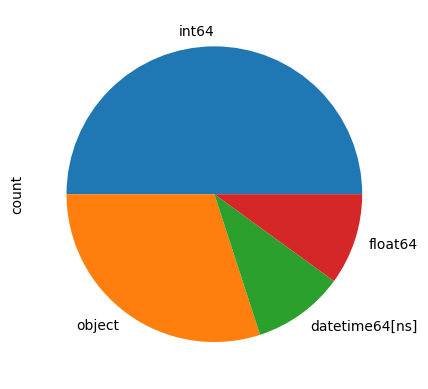

<Figure size 2000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df1.dtypes.value_counts().plot.pie()
plt.figure(figsize=(20,10))

In [ ]:
colonne1=[]
for colonne in df1.columns:
  if df1[colonne].isna().sum()!=0:
    colonne1.append(colonne)

df1.isna().sum()

index                0
CODE_AGENCE          0
DEV                  0
CODE_OPERATION       0
LIBELLE_OPERATION    0
INTITULE_COMPTE      0
PERIODE              0
SENS                 0
NB_OPERATION         0
MONTANT              0
dtype: int64

In [ ]:
colonne2=[]
for colonne in df1.columns:
  if df1[colonne].isna().sum()!=0:
    colonne2.append(colonne)

df2.isna().sum()

Index                0
CODE_AGENCE          0
DEV                  0
CODE_OPERATION       0
LIBELLE_OPERATION    0
INTITULE_COMPTE      0
PERIODE              0
SENS                 0
NB_OPERATION         0
MONTANT              0
dtype: int64

# Training


In [ ]:
df1['PERIODE'] = pd.to_datetime(df1['PERIODE'])

df1['year'] = df1['PERIODE'].dt.year
df1['month'] = df1['PERIODE'].dt.month
df1['day'] = df1['PERIODE'].dt.day

df=df1.copy()


# Sens : C - 1, D - 0
df['SENS_BIN'] = (df['SENS'].str.strip() == 'C').astype(int)
# Montant en valeur absolue 
df['MONTANT_ABS'] = df['MONTANT'].abs()

# Soldes initiaux 
df0.columns = df0.columns.str.strip().str.upper()
df0['DCO'] = pd.to_datetime(df0['DCO'], dayfirst=True)

# Renommer pour fusionner
df0 = df0.rename(columns={
    'AGE': 'CODE_AGENCE',
    'SDE': 'SOLDE_INITIAL'
})

# Garder le solde le plus récent par agence
solde_map = (
    df0.sort_values('DCO')
    .groupby('CODE_AGENCE')['SOLDE_INITIAL']
    .last()
    .reset_index()
)

# Creation d'un nouveau dataframe (fusion)
df = df.merge(solde_map, on='CODE_AGENCE', how='left')
df['SOLDE_INITIAL'] = df['SOLDE_INITIAL'].fillna(0)

print(f'Dataset fusionné : {df.shape}')
print(f'Valeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df

Dataset fusionné : (406258, 16)
Valeurs manquantes :
Series([], dtype: int64)


,index,CODE_AGENCE,DEV,CODE_OPERATION,LIBELLE_OPERATION,INTITULE_COMPTE,PERIODE,SENS,NB_OPERATION,MONTANT,year,month,day,SENS_BIN,MONTANT_ABS,SOLDE_INITIAL
0,1373958,8,788,101,TRANSFERT INTER CAISSES ESP,CAISSE DINARS,2023-03-03,C,1,140000.00,2023,3,3,1,140000.00,-0.00
1,1373959,8,788,123,RETRAIT MAD,CAISSE DINARS,2023-01-11,C,1,300.00,2023,1,11,1,300.00,-0.00
2,1373960,8,788,194,RET TND SUR CPT DEV(ESCOMPTE),CAISSE DINARS,2023-01-24,C,1,16000.00,2023,1,24,1,16000.00,-0.00
3,1373961,8,788,255,ENVOI FONDS BILLETS,CAISSE DINARS,2023-04-04,C,1,30000.00,2023,4,4,1,30000.00,-0.00
4,1373962,8,788,306,WESTERN UNION,CAISSE DINARS,2023-07-21,C,1,275.86,2023,7,21,1,275.86,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406253,2113413,103,788,70,ACHAT PREP,CAISSE DINARS,2023-06-09,D,3,-50.70,2023,6,9,0,50.70,-0.00
406254,2113414,103,788,102,VERSEMENT ESPECE,CAISSE DINARS,2023-07-06,D,37,-111317.10,2023,7,6,0,111317.10,-0.00
406255,2113415,103,788,102,VERSEMENT ESPECE,CAISSE DINARS,2023-08-04,D,30,-93989.50,2023,8,4,0,93989.50,-0.00
406256,2113416,103,788,101,TRANSFERT INTER CAISSES ESP,CAISSE DINARS,2023-12-07,D,2,-57152.84,2023,12,7,0,57152.84,-0.00


## Analyse explorative

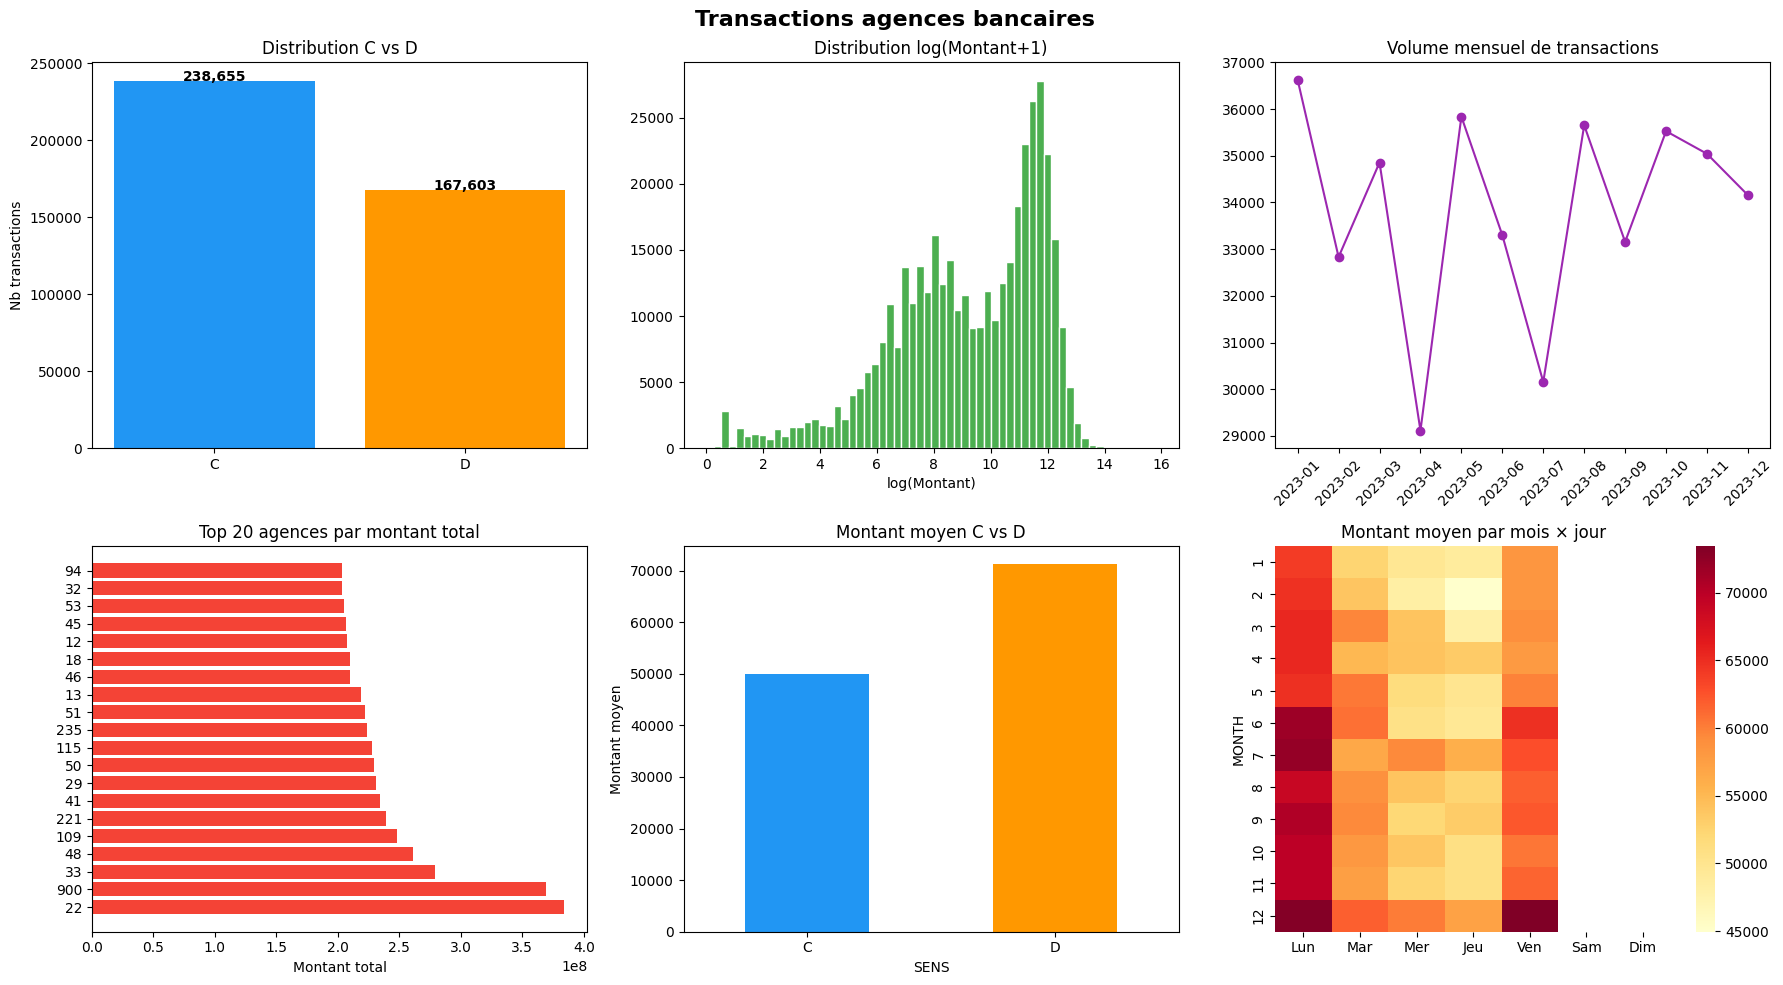

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Transactions agences bancaires', fontsize=16, fontweight='bold')

# Distribution C vs D
counts = df['SENS'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=['#2196F3','#FF9800'])
axes[0,0].set_title('Distribution C vs D')
axes[0,0].set_ylabel('Nb transactions')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Distribution des montants (log scale)
axes[0,1].hist(np.log1p(df['MONTANT_ABS']), bins=60, color='#4CAF50', edgecolor='white')
axes[0,1].set_title('Distribution log(Montant+1)')
axes[0,1].set_xlabel('log(Montant)')

# Transactions par mois
monthly = df.groupby(df['PERIODE'].dt.to_period('M')).size()
axes[0,2].plot(monthly.index.astype(str), monthly.values, marker='o', color='#9C27B0')
axes[0,2].set_title('Volume mensuel de transactions')
axes[0,2].tick_params(axis='x', rotation=45)

# Top 20 agences par volume
top_agences = df.groupby('CODE_AGENCE')['MONTANT_ABS'].sum().nlargest(20)
axes[1,0].barh(top_agences.index.astype(str), top_agences.values, color='#F44336')
axes[1,0].set_title('Top 20 agences par montant total')
axes[1,0].set_xlabel('Montant total')

# Montant moyen C vs D
df.groupby('SENS')['MONTANT_ABS'].mean().plot(kind='bar', ax=axes[1,1], color=['#2196F3','#FF9800'])
axes[1,1].set_title('Montant moyen C vs D')
axes[1,1].set_ylabel('Montant moyen')
axes[1,1].tick_params(axis='x', rotation=0)

# Heatmap : transactions par jour de semaine et mois
df['DOW'] = df['PERIODE'].dt.dayofweek
df['MONTH'] = df['PERIODE'].dt.month

pivot = df.groupby(['MONTH','DOW'])['MONTANT_ABS'].mean().unstack()

# Forcer les 7 jours (0 = Lun, 6 = Dim)
pivot = pivot.reindex(columns=range(7))

pivot.columns = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

sns.heatmap(pivot, ax=axes[1,2], cmap='YlOrRd', fmt='.0f')
axes[1,2].set_title('Montant moyen par mois × jour')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## Deternmination des 'features'

In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construit les features par agence × jour.
    Chaque ligne = une opération d'une agence un jour donné.
    """
    df = df.sort_values(['CODE_AGENCE', 'PERIODE']).copy()

    # ── Calendrier ───────────────────────────────────────────────
    df['DAY_OF_WEEK']   = df['PERIODE'].dt.dayofweek          # 0=Lun
    df['DAY_OF_MONTH']  = df['PERIODE'].dt.day
    df['MONTH']         = df['PERIODE'].dt.month
    df['QUARTER']       = df['PERIODE'].dt.quarter
    df['IS_MONTH_END']  = df['PERIODE'].dt.is_month_end.astype(int)
    df['IS_MONTH_START']= df['PERIODE'].dt.is_month_start.astype(int)
    df['IS_WEEKEND']    = (df['DAY_OF_WEEK'] >= 5).astype(int)
    # Encodage cyclique du mois et du jour
    df['MONTH_SIN']     = np.sin(2 * np.pi * df['MONTH'] / 12)
    df['MONTH_COS']     = np.cos(2 * np.pi * df['MONTH'] / 12)
    df['DOW_SIN']       = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7)
    df['DOW_COS']       = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7)

    # ── Lag features par agence (montant et sens) ─────────────────
    grp = df.groupby('CODE_AGENCE')
    for lag in [1, 3, 7, 14, 30]:
        df[f'MONTANT_LAG_{lag}']  = grp['MONTANT_ABS'].shift(lag)
        df[f'SENS_LAG_{lag}']     = grp['SENS_BIN'].shift(lag)

    # ── Rolling statistics par agence ─────────────────────────────
    for window in [7, 14, 30]:
        roll = grp['MONTANT_ABS'].shift(1).rolling(window)
        df[f'MONTANT_ROLL_MEAN_{window}'] = roll.mean().reset_index(level=0, drop=True)
        df[f'MONTANT_ROLL_STD_{window}']  = roll.std().reset_index(level=0, drop=True)
        df[f'MONTANT_ROLL_MAX_{window}']  = roll.max().reset_index(level=0, drop=True)
        df[f'MONTANT_ROLL_MIN_{window}']  = roll.min().reset_index(level=0, drop=True)

    # ── Solde courant estimé ──────────────────────────────────────
    # solde_courant = solde_initial + cumsum des montants signés
    df['MONTANT_SIGNE'] = df.apply(
        lambda r: r['MONTANT_ABS'] if r['SENS_BIN'] == 1 else -r['MONTANT_ABS'], axis=1
    )
    df['SOLDE_CUMUL'] = (
        df.groupby('CODE_AGENCE')['MONTANT_SIGNE']
        .cumsum()
        .shift(1)  # on ne connaît pas encore le montant du jour courant
    )
    df['SOLDE_COURANT'] = df['SOLDE_INITIAL'] + df['SOLDE_CUMUL'].fillna(0)

    # ── Statistiques agence globales ──────────────────────────────
    stats_agence = df.groupby('CODE_AGENCE').agg(
        NB_TOTAL_OPS      = ('MONTANT_ABS', 'count'),
        MONTANT_MOYEN_AGE = ('MONTANT_ABS', 'mean'),
        PROP_C_AGE        = ('SENS_BIN', 'mean'),
    ).reset_index()
    df = df.merge(stats_agence, on='CODE_AGENCE', how='left')

    # ── NB_OPERATION comme feature ────────────────────────────────
    df['LOG_NB_OPERATION'] = np.log1p(df['NB_OPERATION'])

    # ── Log-montant cible ─────────────────────────────────────────
    df['LOG_MONTANT'] = np.log1p(df['MONTANT_ABS'])

    return df


df_feat = build_features(df)
print(f'Features construites : {df_feat.shape}')
print(f'Nouvelles colonnes : {[c for c in df_feat.columns if c not in df.columns]}')

Features construites : (406258, 58)
Nouvelles colonnes : ['DAY_OF_WEEK', 'DAY_OF_MONTH', 'QUARTER', 'IS_MONTH_END', 'IS_MONTH_START', 'IS_WEEKEND', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'MONTANT_LAG_1', 'SENS_LAG_1', 'MONTANT_LAG_3', 'SENS_LAG_3', 'MONTANT_LAG_7', 'SENS_LAG_7', 'MONTANT_LAG_14', 'SENS_LAG_14', 'MONTANT_LAG_30', 'SENS_LAG_30', 'MONTANT_ROLL_MEAN_7', 'MONTANT_ROLL_STD_7', 'MONTANT_ROLL_MAX_7', 'MONTANT_ROLL_MIN_7', 'MONTANT_ROLL_MEAN_14', 'MONTANT_ROLL_STD_14', 'MONTANT_ROLL_MAX_14', 'MONTANT_ROLL_MIN_14', 'MONTANT_ROLL_MEAN_30', 'MONTANT_ROLL_STD_30', 'MONTANT_ROLL_MAX_30', 'MONTANT_ROLL_MIN_30', 'MONTANT_SIGNE', 'SOLDE_CUMUL', 'SOLDE_COURANT', 'NB_TOTAL_OPS', 'MONTANT_MOYEN_AGE', 'PROP_C_AGE', 'LOG_NB_OPERATION', 'LOG_MONTANT']


In [ ]:
# Supprimer les lignes avec NaN dans les features lag (début de série)
from sklearn.preprocessing import LabelEncoder


FEATURE_COLS = [
    # Calendrier
    'DAY_OF_WEEK','DAY_OF_MONTH','MONTH','QUARTER',
    'IS_MONTH_END','IS_MONTH_START','IS_WEEKEND',
    'MONTH_SIN','MONTH_COS','DOW_SIN','DOW_COS',
    # Lags
    'MONTANT_LAG_1','MONTANT_LAG_3','MONTANT_LAG_7','MONTANT_LAG_14','MONTANT_LAG_30',
    'SENS_LAG_1','SENS_LAG_3','SENS_LAG_7','SENS_LAG_14','SENS_LAG_30',
    # Rolling
    'MONTANT_ROLL_MEAN_7','MONTANT_ROLL_STD_7','MONTANT_ROLL_MAX_7','MONTANT_ROLL_MIN_7',
    'MONTANT_ROLL_MEAN_14','MONTANT_ROLL_STD_14',
    'MONTANT_ROLL_MEAN_30','MONTANT_ROLL_STD_30',
    # Solde
    'SOLDE_COURANT','SOLDE_INITIAL',
    # Agence
    'CODE_AGENCE','DEV','CODE_OPERATION',
    'NB_TOTAL_OPS','MONTANT_MOYEN_AGE','PROP_C_AGE',
    'LOG_NB_OPERATION',
]

TARGET_CLF  = 'SENS_BIN'       # 1=C, 0=D
TARGET_REG  = 'LOG_MONTANT'    # log(montant+1)

df_model = df_feat.dropna(subset=[c for c in FEATURE_COLS if c in df_feat.columns])
df_model = df_model.sort_values('PERIODE').reset_index(drop=True)

# Split temporel : 80% train, 10% val, 10% test
n = len(df_model)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

df_train = df_model.iloc[:train_end]
df_val   = df_model.iloc[train_end:val_end]
df_test  = df_model.iloc[val_end:]

print(f'Train : {df_train.shape}  ({df_train["PERIODE"].min()} → {df_train["PERIODE"].max()})')
print(f'Val   : {df_val.shape}  ({df_val["PERIODE"].min()} → {df_val["PERIODE"].max()})')
print(f'Test  : {df_test.shape}  ({df_test["PERIODE"].min()} → {df_test["PERIODE"].max()})')

# Features numériques seulement pour XGBoost (encode les catégorielles)
CAT_COLS = ['CODE_AGENCE','DEV','CODE_OPERATION']
for c in CAT_COLS:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c].astype(str))

FEAT_NUM = [c for c in FEATURE_COLS if c in df_model.columns]

X_train = df_train[FEAT_NUM].fillna(0)
X_val   = df_val[FEAT_NUM].fillna(0)
X_test  = df_test[FEAT_NUM].fillna(0)

y_clf_train, y_clf_val, y_clf_test = df_train[TARGET_CLF], df_val[TARGET_CLF], df_test[TARGET_CLF]
y_reg_train, y_reg_val, y_reg_test = df_train[TARGET_REG], df_val[TARGET_REG], df_test[TARGET_REG]

print(f'\nNb features : {len(FEAT_NUM)}')
print(f'Balance classes (train) : C={y_clf_train.mean():.2%} D={(1-y_clf_train.mean()):.2%}')

Train : (315486, 58)  (2023-01-04 00:00:00 → 2023-10-23 00:00:00)
Val   : (39436, 58)  (2023-10-23 00:00:00 → 2023-11-27 00:00:00)
Test  : (39436, 58)  (2023-11-27 00:00:00 → 2023-12-29 00:00:00)

Nb features : 38
Balance classes (train) : C=58.86% D=41.14%


### Modèle XGboost pour la classification (C/D)

In [ ]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    gamma              = 0.1,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = (y_clf_train == 0).sum() / (y_clf_train == 1).sum(),
    use_label_encoder  = False,
    eval_metric        = 'logloss',
    early_stopping_rounds = 30,
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
    tree_method        = 'hist',
)

xgb_clf.fit(
    X_train, y_clf_train,
    eval_set=[(X_val, y_clf_val)],
    verbose=50
)

# Évaluation
y_pred_clf  = xgb_clf.predict(X_test)
y_proba_clf = xgb_clf.predict_proba(X_test)[:,1]

print('\n=== Rapport Classification XGBoost ===')
print(classification_report(y_clf_test, y_pred_clf, target_names=['D (Versement)','C (Commande)']))
print(f'AUC-ROC : {roc_auc_score(y_clf_test, y_proba_clf):.4f}')
print(f'F1 macro : {f1_score(y_clf_test, y_pred_clf, average="macro"):.4f}')

[0]	validation_0-logloss:0.65306
[50]	validation_0-logloss:0.16936
[100]	validation_0-logloss:0.12707
[150]	validation_0-logloss:0.12036
[200]	validation_0-logloss:0.11823
[250]	validation_0-logloss:0.11725
[300]	validation_0-logloss:0.11649
[350]	validation_0-logloss:0.11619
[400]	validation_0-logloss:0.11589
[450]	validation_0-logloss:0.11565
[499]	validation_0-logloss:0.11554

=== Rapport Classification XGBoost ===
               precision    recall  f1-score   support

D (Versement)       0.90      0.95      0.93     16561
 C (Commande)       0.97      0.93      0.94     22875

     accuracy                           0.94     39436
    macro avg       0.93      0.94      0.94     39436
 weighted avg       0.94      0.94      0.94     39436

AUC-ROC : 0.9908
F1 macro : 0.9363


### Modèle XGboust pour l'estimation du monatant

In [ ]:
xgb_reg = xgb.XGBRegressor(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    objective          = 'reg:squarederror',
    eval_metric        = 'rmse',
    early_stopping_rounds = 30,
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
    tree_method        = 'hist',
)

xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_val, y_reg_val)],
    verbose=50
)

# Prédictions en espace original (expm1 inverse du log1p)
y_pred_reg_log = xgb_reg.predict(X_test)
y_pred_reg     = np.expm1(np.clip(y_pred_reg_log, 0, None))
y_true_reg     = np.expm1(y_reg_test)

mae  = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
mape = np.mean(np.abs((y_true_reg - y_pred_reg) / (y_true_reg + 1))) * 100

print('\n=== Métriques Régression XGBoost ===')
print(f'MAE  : {mae:,.0f}')
print(f'RMSE : {rmse:,.0f}')
print(f'MAPE : {mape:.2f}%')

[0]	validation_0-rmse:2.52240
[50]	validation_0-rmse:1.07953
[100]	validation_0-rmse:0.99561
[150]	validation_0-rmse:0.97744
[200]	validation_0-rmse:0.97019
[250]	validation_0-rmse:0.96288
[300]	validation_0-rmse:0.95750
[350]	validation_0-rmse:0.95233
[400]	validation_0-rmse:0.94827
[450]	validation_0-rmse:0.94539
[499]	validation_0-rmse:0.94232

=== Métriques Régression XGBoost ===
MAE  : 25,320
RMSE : 71,213
MAPE : 170.27%


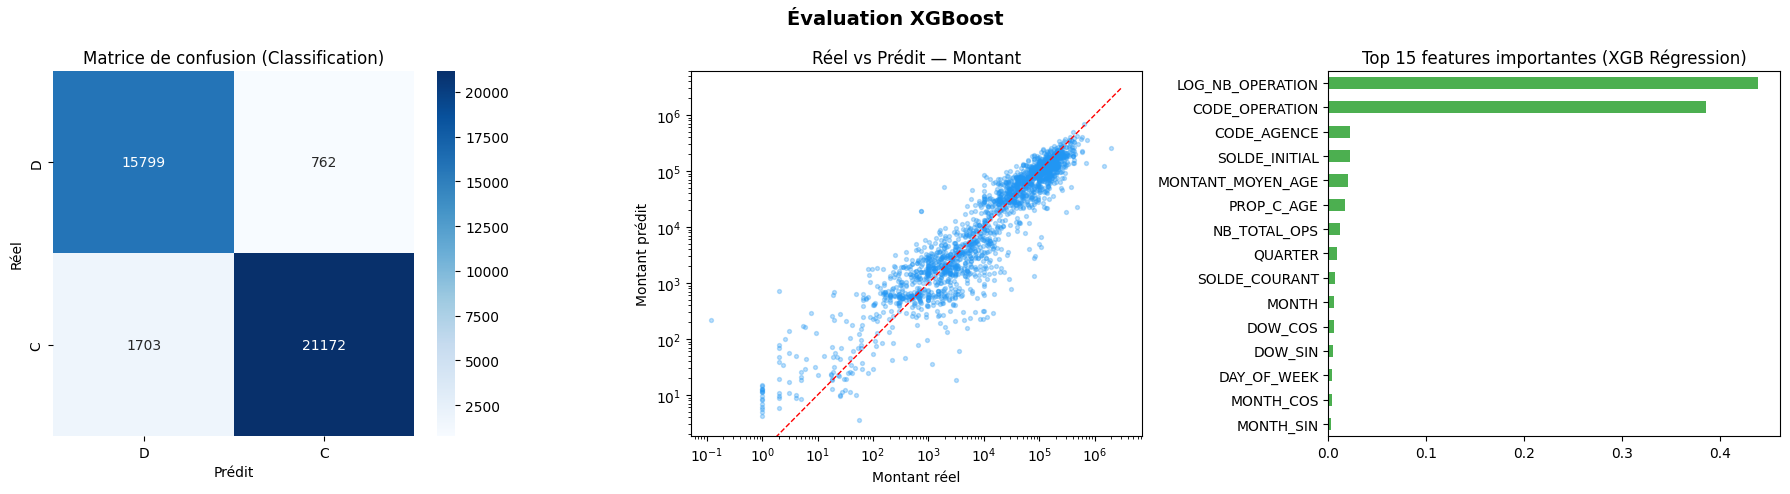

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Évaluation XGBoost', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_clf_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['D','C'], yticklabels=['D','C'])
axes[0].set_title('Matrice de confusion (Classification)')
axes[0].set_xlabel('Prédit') ; axes[0].set_ylabel('Réel')

# Réel vs Prédit (montant)
sample_idx = np.random.choice(len(y_true_reg), min(2000, len(y_true_reg)), replace=False)
axes[1].scatter(y_true_reg.values[sample_idx], y_pred_reg[sample_idx],
                alpha=0.3, s=8, color='#2196F3')
max_val = max(y_true_reg.max(), y_pred_reg.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[1].set_title('Réel vs Prédit — Montant')
axes[1].set_xlabel('Montant réel') ; axes[1].set_ylabel('Montant prédit')
axes[1].set_xscale('log') ; axes[1].set_yscale('log')

# Importance des features (top 15)
importances = pd.Series(xgb_reg.feature_importances_, index=FEAT_NUM).nlargest(15)
importances.plot(kind='barh', ax=axes[2], color='#4CAF50')
axes[2].set_title('Top 15 features importantes (XGB Régression)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('xgboost_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

# Essai avec les données de 2024

In [ ]:
df2['PERIODE'] = pd.to_datetime(df2['PERIODE'])



df2['year'] = df2['PERIODE'].dt.year
df2['month'] = df2['PERIODE'].dt.month
df2['day'] = df2['PERIODE'].dt.day


print(df1.columns)
print(df2.columns)
#df3.columns=df1.columns
#print(df3.columns)


df_final = pd.concat([df1, df2])

df_final.columns

Index(['index', 'CODE_AGENCE', 'DEV', 'CODE_OPERATION', 'LIBELLE_OPERATION',
       'INTITULE_COMPTE', 'PERIODE', 'SENS', 'NB_OPERATION', 'MONTANT', 'year',
       'month', 'day'],
      dtype='object')
Index(['Index', 'CODE_AGENCE', 'DEV', 'CODE_OPERATION', 'LIBELLE_OPERATION',
       'INTITULE_COMPTE', 'PERIODE', 'SENS', 'NB_OPERATION', 'MONTANT', 'year',
       'month', 'day'],
      dtype='object')


Index(['index', 'CODE_AGENCE', 'DEV', 'CODE_OPERATION', 'LIBELLE_OPERATION',
       'INTITULE_COMPTE', 'PERIODE', 'SENS', 'NB_OPERATION', 'MONTANT', 'year',
       'month', 'day', 'Index'],
      dtype='object')

In [ ]:
# Sens : C - 1, D - 0
df_final['SENS_BIN'] = (df_final['SENS'].str.strip() == 'C').astype(int)
# Montant en valeur absolue 
df_final['MONTANT_ABS'] = df_final['MONTANT'].abs()

# Soldes initiaux 
df0.columns = df0.columns.str.strip().str.upper()
df0['DCO'] = pd.to_datetime(df0['DCO'], dayfirst=True)

# Renommer pour fusionner
df0 = df0.rename(columns={
    'AGE': 'CODE_AGENCE',
    'SDE': 'SOLDE_INITIAL'
})

# Garder le solde le plus récent par agence
solde_map = (
    df0.sort_values('DCO')
    .groupby('CODE_AGENCE')['SOLDE_INITIAL']
    .last()
    .reset_index()
)

# Creation d'un nouveau dataframe (fusion)
df_final = df_final.merge(solde_map, on='CODE_AGENCE', how='left')
df_final['SOLDE_INITIAL'] = df_final['SOLDE_INITIAL'].fillna(0)

print(f'Dataset fusionné : {df_final.shape}')
print(f'Valeurs manquantes :\n{df_final.isnull().sum()[df_final.isnull().sum() > 0]}')
df_final

Dataset fusionné : (802435, 17)
Valeurs manquantes :
index    396177
Index    406258
dtype: int64


,index,CODE_AGENCE,DEV,CODE_OPERATION,LIBELLE_OPERATION,INTITULE_COMPTE,PERIODE,SENS,NB_OPERATION,MONTANT,year,month,day,Index,SENS_BIN,MONTANT_ABS,SOLDE_INITIAL
0,1373958.00,8,788,101,TRANSFERT INTER CAISSES ESP,CAISSE DINARS,2023-03-03,C,1,140000.00,2023,3,3,NaN,1,140000.00,-0.00
1,1373959.00,8,788,123,RETRAIT MAD,CAISSE DINARS,2023-01-11,C,1,300.00,2023,1,11,NaN,1,300.00,-0.00
2,1373960.00,8,788,194,RET TND SUR CPT DEV(ESCOMPTE),CAISSE DINARS,2023-01-24,C,1,16000.00,2023,1,24,NaN,1,16000.00,-0.00
3,1373961.00,8,788,255,ENVOI FONDS BILLETS,CAISSE DINARS,2023-04-04,C,1,30000.00,2023,4,4,NaN,1,30000.00,-0.00
4,1373962.00,8,788,306,WESTERN UNION,CAISSE DINARS,2023-07-21,C,1,275.86,2023,7,21,NaN,1,275.86,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802430,NaN,187,788,164,ACHAT DEVISES,CAISSE DINARS,2024-05-17,C,2,-502.80,2024,5,17,1373916.00,1,502.80,-0.00
802431,NaN,187,788,164,ACHAT DEVISES,CAISSE DINARS,2024-05-29,C,1,-3350.00,2024,5,29,1373917.00,1,3350.00,-0.00
802432,NaN,187,788,164,ACHAT DEVISES,CAISSE DINARS,2024-09-20,C,1,-503.40,2024,9,20,1373918.00,1,503.40,-0.00
802433,NaN,187,788,255,ENVOI FONDS BILLETS,CAISSE DINARS,2024-10-08,C,1,-200000.00,2024,10,8,1373919.00,1,200000.00,-0.00


In [ ]:
df_feat = build_features(df_final)
print(f'Features construites : {df_feat.shape}')
print(f'Nouvelles colonnes : {[c for c in df_feat.columns if c not in df_final.columns]}')

Features construites : (802435, 58)
Nouvelles colonnes : ['DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH', 'QUARTER', 'IS_MONTH_END', 'IS_MONTH_START', 'IS_WEEKEND', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'MONTANT_LAG_1', 'SENS_LAG_1', 'MONTANT_LAG_3', 'SENS_LAG_3', 'MONTANT_LAG_7', 'SENS_LAG_7', 'MONTANT_LAG_14', 'SENS_LAG_14', 'MONTANT_LAG_30', 'SENS_LAG_30', 'MONTANT_ROLL_MEAN_7', 'MONTANT_ROLL_STD_7', 'MONTANT_ROLL_MAX_7', 'MONTANT_ROLL_MIN_7', 'MONTANT_ROLL_MEAN_14', 'MONTANT_ROLL_STD_14', 'MONTANT_ROLL_MAX_14', 'MONTANT_ROLL_MIN_14', 'MONTANT_ROLL_MEAN_30', 'MONTANT_ROLL_STD_30', 'MONTANT_ROLL_MAX_30', 'MONTANT_ROLL_MIN_30', 'MONTANT_SIGNE', 'SOLDE_CUMUL', 'SOLDE_COURANT', 'NB_TOTAL_OPS', 'MONTANT_MOYEN_AGE', 'PROP_C_AGE', 'LOG_NB_OPERATION', 'LOG_MONTANT']


In [ ]:
FEATURE_COLS = [
    # Calendrier
    'DAY_OF_WEEK','DAY_OF_MONTH','MONTH','QUARTER',
    'IS_MONTH_END','IS_MONTH_START','IS_WEEKEND',
    'MONTH_SIN','MONTH_COS','DOW_SIN','DOW_COS',
    # Lags
    'MONTANT_LAG_1','MONTANT_LAG_3','MONTANT_LAG_7','MONTANT_LAG_14','MONTANT_LAG_30',
    'SENS_LAG_1','SENS_LAG_3','SENS_LAG_7','SENS_LAG_14','SENS_LAG_30',
    # Rolling
    'MONTANT_ROLL_MEAN_7','MONTANT_ROLL_STD_7','MONTANT_ROLL_MAX_7','MONTANT_ROLL_MIN_7',
    'MONTANT_ROLL_MEAN_14','MONTANT_ROLL_STD_14',
    'MONTANT_ROLL_MEAN_30','MONTANT_ROLL_STD_30',
    # Solde
    'SOLDE_COURANT','SOLDE_INITIAL',
    # Agence
    'CODE_AGENCE','DEV','CODE_OPERATION',
    'NB_TOTAL_OPS','MONTANT_MOYEN_AGE','PROP_C_AGE',
    'LOG_NB_OPERATION',
]

TARGET_CLF  = 'SENS_BIN'       # 1=C, 0=D
TARGET_REG  = 'LOG_MONTANT'    # log(montant+1)

df_model = df_feat.dropna(subset=[c for c in FEATURE_COLS if c in df_feat.columns])
df_model = df_model.sort_values('PERIODE').reset_index(drop=True)

# Split temporel : 80% train, 10% val, 10% test
n = len(df_model)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

df_train = df_model.iloc[:train_end]
df_val   = df_model.iloc[train_end:val_end]
df_test  = df_model.iloc[val_end:]

print(f'Train : {df_train.shape}  ({df_train["PERIODE"].min()} → {df_train["PERIODE"].max()})')
print(f'Val   : {df_val.shape}  ({df_val["PERIODE"].min()} → {df_val["PERIODE"].max()})')
print(f'Test  : {df_test.shape}  ({df_test["PERIODE"].min()} → {df_test["PERIODE"].max()})')

# Features numériques seulement pour XGBoost (encode les catégorielles)
CAT_COLS = ['CODE_AGENCE','DEV','CODE_OPERATION']
for c in CAT_COLS:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c].astype(str))

FEAT_NUM = [c for c in FEATURE_COLS if c in df_model.columns]

X_train = df_train[FEAT_NUM].fillna(0)
X_val   = df_val[FEAT_NUM].fillna(0)
X_test  = df_test[FEAT_NUM].fillna(0)

y_clf_train, y_clf_val, y_clf_test = df_train[TARGET_CLF], df_val[TARGET_CLF], df_test[TARGET_CLF]
y_reg_train, y_reg_val, y_reg_test = df_train[TARGET_REG], df_val[TARGET_REG], df_test[TARGET_REG]

print(f'\nNb features : {len(FEAT_NUM)}')
print(f'Balance classes (train) : C={y_clf_train.mean():.2%} D={(1-y_clf_train.mean()):.2%}')

Train : (632319, 58)  (2023-01-04 00:00:00 → 2024-08-08 00:00:00)
Val   : (79040, 58)  (2024-08-08 00:00:00 → 2024-10-21 00:00:00)
Test  : (79040, 58)  (2024-10-21 00:00:00 → 2024-12-31 00:00:00)

Nb features : 38
Balance classes (train) : C=58.71% D=41.29%


In [ ]:
xgb_clf = xgb.XGBClassifier(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    gamma              = 0.1,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = (y_clf_train == 0).sum() / (y_clf_train == 1).sum(),
    use_label_encoder  = False,
    eval_metric        = 'logloss',
    early_stopping_rounds = 30,
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
    tree_method        = 'hist',
)

xgb_clf.fit(
    X_train, y_clf_train,
    eval_set=[(X_val, y_clf_val)],
    verbose=50
)

# Évaluation
y_pred_clf  = xgb_clf.predict(X_test)
y_proba_clf = xgb_clf.predict_proba(X_test)[:,1]

print('\n=== Rapport Classification XGBoost ===')
print(classification_report(y_clf_test, y_pred_clf, target_names=['D (Versement)','C (Commande)']))
print(f'AUC-ROC : {roc_auc_score(y_clf_test, y_proba_clf):.4f}')
print(f'F1 macro : {f1_score(y_clf_test, y_pred_clf, average="macro"):.4f}')

[0]	validation_0-logloss:0.65253
[50]	validation_0-logloss:0.16266
[100]	validation_0-logloss:0.12009
[150]	validation_0-logloss:0.11322
[200]	validation_0-logloss:0.11070
[250]	validation_0-logloss:0.10912
[300]	validation_0-logloss:0.10828
[350]	validation_0-logloss:0.10773
[400]	validation_0-logloss:0.10730
[450]	validation_0-logloss:0.10703
[499]	validation_0-logloss:0.10679

=== Rapport Classification XGBoost ===
               precision    recall  f1-score   support

D (Versement)       0.91      0.95      0.93     34173
 C (Commande)       0.96      0.92      0.94     44867

     accuracy                           0.94     79040
    macro avg       0.93      0.94      0.94     79040
 weighted avg       0.94      0.94      0.94     79040

AUC-ROC : 0.9904
F1 macro : 0.9358


In [ ]:
xgb_reg = xgb.XGBRegressor(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    objective          = 'reg:squarederror',
    eval_metric        = 'rmse',
    early_stopping_rounds = 30,
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
    tree_method        = 'hist',
)

xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_val, y_reg_val)],
    verbose=50
)

# Prédictions en espace original (expm1 inverse du log1p)
y_pred_reg_log = xgb_reg.predict(X_test)
y_pred_reg     = np.expm1(np.clip(y_pred_reg_log, 0, None))
y_true_reg     = np.expm1(y_reg_test)

mae  = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
mape = np.mean(np.abs((y_true_reg - y_pred_reg) / (y_true_reg + 1))) * 100

print('\n=== Métriques Régression XGBoost ===')
print(f'MAE  : {mae:,.0f}')
print(f'RMSE : {rmse:,.0f}')
print(f'MAPE : {mape:.2f}%')

[0]	validation_0-rmse:2.52427
[50]	validation_0-rmse:1.10318
[100]	validation_0-rmse:1.01618
[150]	validation_0-rmse:0.99964
[200]	validation_0-rmse:0.98913
[250]	validation_0-rmse:0.98280
[300]	validation_0-rmse:0.97624
[350]	validation_0-rmse:0.97106
[400]	validation_0-rmse:0.96665
[450]	validation_0-rmse:0.96334
[499]	validation_0-rmse:0.96059

=== Métriques Régression XGBoost ===
MAE  : 26,370
RMSE : 98,729
MAPE : 141.74%


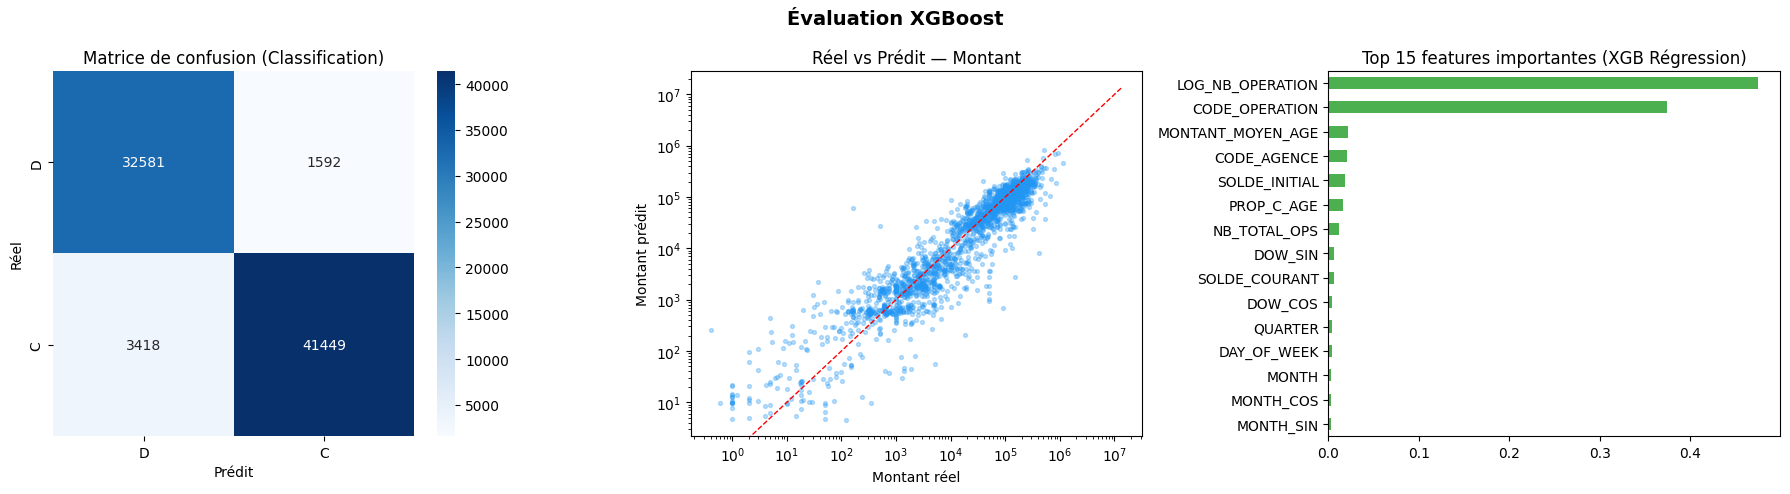

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Évaluation XGBoost', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_clf_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['D','C'], yticklabels=['D','C'])
axes[0].set_title('Matrice de confusion (Classification)')
axes[0].set_xlabel('Prédit') ; axes[0].set_ylabel('Réel')

# Réel vs Prédit (montant)
sample_idx = np.random.choice(len(y_true_reg), min(2000, len(y_true_reg)), replace=False)
axes[1].scatter(y_true_reg.values[sample_idx], y_pred_reg[sample_idx],
                alpha=0.3, s=8, color='#2196F3')
max_val = max(y_true_reg.max(), y_pred_reg.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[1].set_title('Réel vs Prédit — Montant')
axes[1].set_xlabel('Montant réel') ; axes[1].set_ylabel('Montant prédit')
axes[1].set_xscale('log') ; axes[1].set_yscale('log')

# Importance des features (top 15)
importances = pd.Series(xgb_reg.feature_importances_, index=FEAT_NUM).nlargest(15)
importances.plot(kind='barh', ax=axes[2], color='#4CAF50')
axes[2].set_title('Top 15 features importantes (XGB Régression)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('xgboost_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Construire un dataframe de résultats sur le jeu de test
df_results = df_test.iloc[-len(y_pred_clf):].copy()
df_results['PRED_SENS']    = np.where(y_pred_clf == 1, 'C', 'D')
df_results['PRED_MONTANT'] = y_pred_reg
df_results['PROBA_C']      = y_proba_clf
df_results['VRAI_SENS']    = np.where(y_clf_test == 1, 'C', 'D')
df_results['VRAI_MONTANT'] = y_true_reg
df_results['ERREUR_ABS']   = (df_results['PRED_MONTANT'] - df_results['VRAI_MONTANT']).abs()
df_results['CORRECT_SENS'] = df_results['PRED_SENS'] == df_results['VRAI_SENS']

# Métriques par agence
per_agence = df_results.groupby('CODE_AGENCE').agg(
    NB_OPS         = ('VRAI_SENS', 'count'),
    ACCURACY_SENS  = ('CORRECT_SENS', 'mean'),
    MAE_MONTANT    = ('ERREUR_ABS', 'mean'),
    MONTANT_MOYEN  = ('VRAI_MONTANT', 'mean'),
).reset_index()
per_agence['MAPE'] = per_agence['MAE_MONTANT'] / (per_agence['MONTANT_MOYEN'] + 1) * 100
per_agence = per_agence.sort_values('ACCURACY_SENS', ascending=False)

print('=== Performance par agence (Top 20) ===')
display(per_agence.head(20))

# Sauvegarder
df_results.to_csv('predictions_test.csv', index=False)
per_agence.to_csv('performance_par_agence.csv', index=False)
print('✅ Fichiers sauvegardés : predictions_test.csv, performance_par_agence.csv')

=== Performance par agence (Top 20) ===


,CODE_AGENCE,NB_OPS,ACCURACY_SENS,MAE_MONTANT,MONTANT_MOYEN,MAPE
80,93,281,1.00,15542.11,46078.84,33.73
79,86,360,1.00,18987.44,46729.13,40.63
190,900,518,1.00,41407.07,106322.68,38.94
191,904,122,0.99,16446.42,42242.25,38.93
140,161,290,0.99,13423.43,27689.71,48.48
170,201,212,0.99,17808.53,40632.02,43.83
10,10,226,0.98,14704.44,28402.09,51.77
176,223,355,0.98,17363.38,55179.11,31.47
66,67,468,0.98,27095.77,75116.04,36.07
161,188,411,0.98,13763.99,32134.13,42.83


✅ Fichiers sauvegardés : predictions_test.csv, performance_par_agence.csv


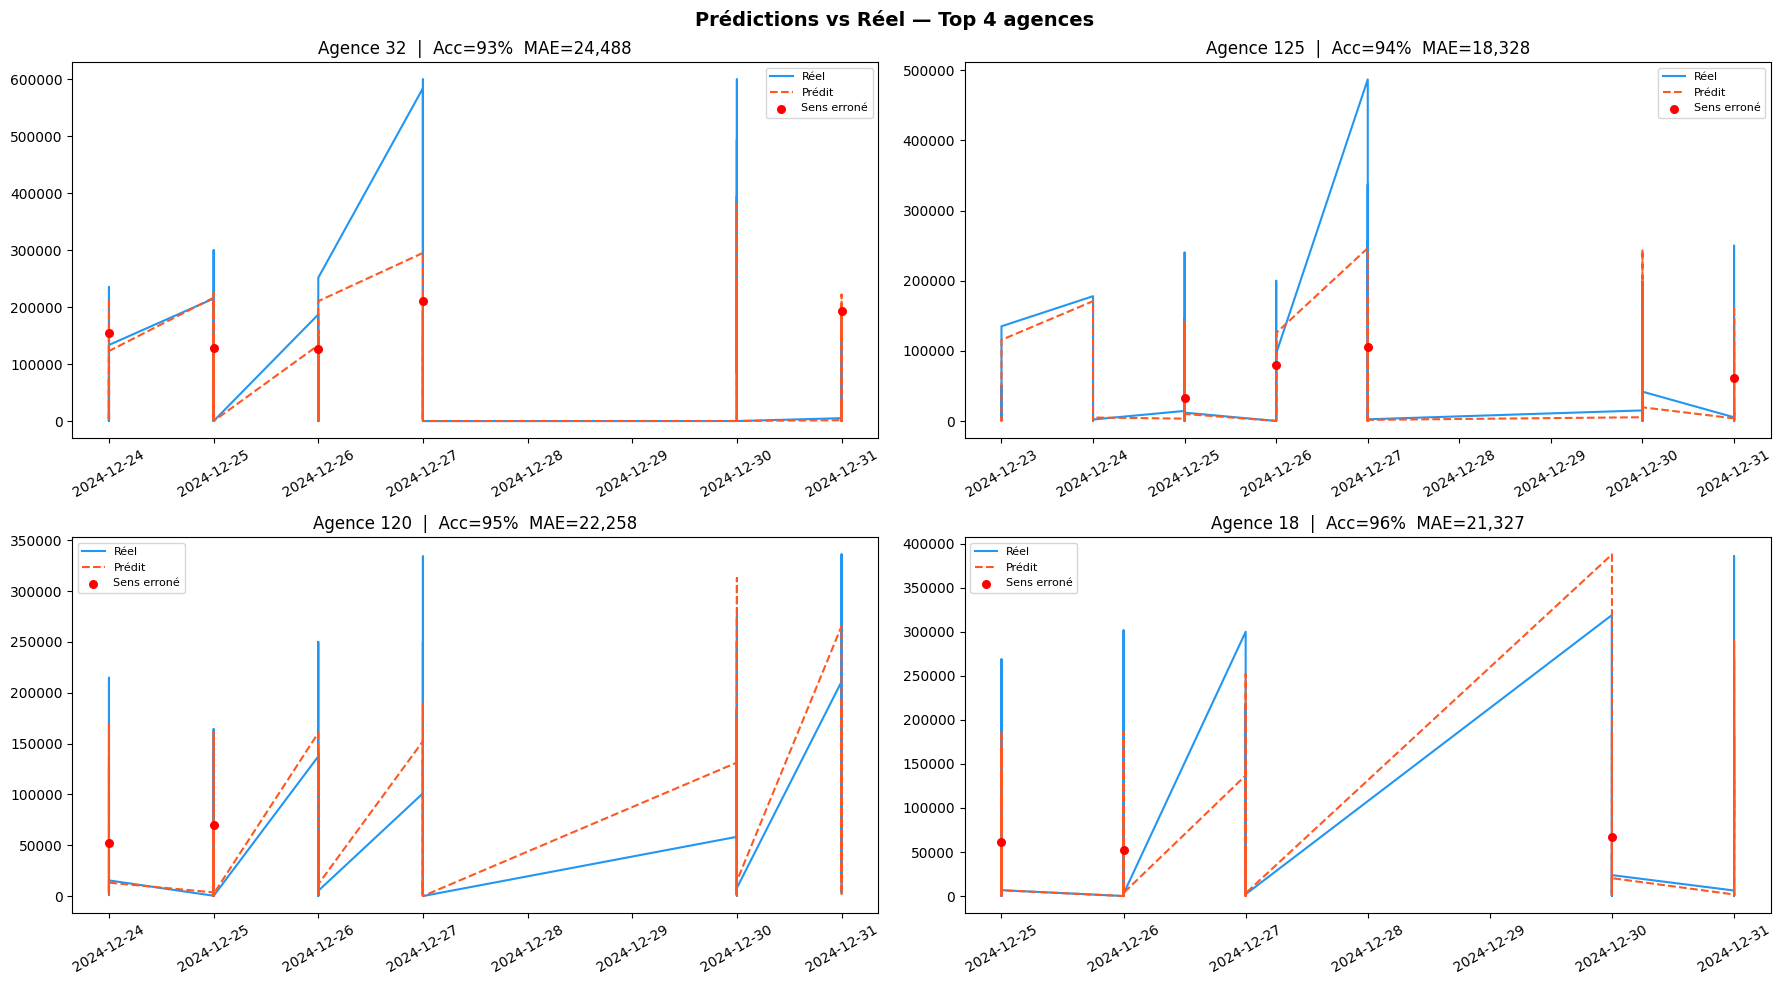

In [ ]:
# Choisir les 4 agences avec le plus d'opérations
top4 = per_agence.nlargest(4, 'NB_OPS')['CODE_AGENCE'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Prédictions vs Réel — Top 4 agences', fontsize=14, fontweight='bold')

for ax, age in zip(axes.flatten(), top4):
    sub = df_results[df_results['CODE_AGENCE'] == age].tail(60)  # 60 dernières ops
    ax.plot(sub['PERIODE'].values, sub['VRAI_MONTANT'].values,
            label='Réel', color='#2196F3', linewidth=1.5)
    ax.plot(sub['PERIODE'].values, sub['PRED_MONTANT'].values,
            label='Prédit', color='#FF5722', linestyle='--', linewidth=1.5)
    # Colorer les erreurs de sens
    erreurs = sub[sub['CORRECT_SENS'] == False]
    ax.scatter(erreurs['PERIODE'].values, erreurs['PRED_MONTANT'].values,
               color='red', s=30, zorder=5, label='Sens erroné')
    acc = per_agence[per_agence['CODE_AGENCE'] == age]['ACCURACY_SENS'].values[0]
    mae_a = per_agence[per_agence['CODE_AGENCE'] == age]['MAE_MONTANT'].values[0]
    ax.set_title(f'Agence {age}  |  Acc={acc:.0%}  MAE={mae_a:,.0f}')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('predictions_par_agence.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import joblib, os

os.makedirs('models', exist_ok=True)

# XGBoost
xgb_clf.save_model('models/xgb_classification.json')
xgb_reg.save_model('models/xgb_regression.json')

# LSTM
#lstm_model.save('models/lstm_multitask.keras')

# Scaler et encodeurs
#joblib.dump(scaler_lstm, 'models/scaler_lstm.pkl')

print('✅ Modèles sauvegardés dans ./models/')
print('  - xgb_classification.json')
print('  - xgb_regression.json')
#print('  - lstm_multitask.keras')
#print('  - scaler_lstm.pkl')

✅ Modèles sauvegardés dans ./models/
  - xgb_classification.json
  - xgb_regression.json


In [ ]:
def predict_next_day(code_agence: int, target_date, df_history: pd.DataFrame) -> dict:
    """
    Pr?dit le montant estim? pour J+1 ? partir d'une date envoy?e.

    Param?tres
    ----------
    code_agence : code unique de l'agence
    target_date : date envoy?e au mod?le
    df_history  : DataFrame de l'historique complet (avec features d?j? calcul?es)

    Retourne
    --------
    dict avec la date envoy?e, la date pr?dite (J+1), le montant et la probabilit? C
    """
    target_date = pd.to_datetime(target_date)
    prediction_date = target_date + pd.Timedelta(days=1)

    hist = df_history[
        (df_history['CODE_AGENCE'] == code_agence)
        & (pd.to_datetime(df_history['PERIODE']) <= target_date)
    ].sort_values('PERIODE')

    if hist.empty:
        return {'erreur': f"Aucun historique pour l'agence {code_agence} jusqu'au {target_date.date()}"}

    last_row = hist[FEAT_NUM].iloc[[-1]].fillna(0)
    proba_c_xgb = xgb_clf.predict_proba(last_row)[0, 1]
    montant_xgb = np.expm1(xgb_reg.predict(last_row)[0])

    return {
        'agence': code_agence,
        'date_envoyee': target_date.date().isoformat(),
        'date_predite': prediction_date.date().isoformat(),
        'montant': round(montant_xgb, 2),
        'proba_C': round(float(proba_c_xgb), 4),
    }


exemple_agence = 1
date_envoyee = pd.Timestamp.today().normalize()

result = predict_next_day(exemple_agence, date_envoyee, df_feat.fillna(0))
print('=== Pr?diction J+1 ===')
for k, v in result.items():
    print(f'  {k:<12} : {v}')


=== Prédiction J+1 ===
  agence       : 1
  montant      : 127873.34375
  proba_C      : 0.0
